# Probability Distributions in AI/ML - Practice Notebook

This notebook contains conceptual and coding questions on Normal, Binomial, and Poisson distributions.

---

## 1. Normal Distribution

**Q1:** Generate a normal distribution with mean=0 and std=1. Plot it.

**Q2:** Simulate exam scores of 1000 students assuming normal distribution. What percentage scored above 85?

**Q3 (Thinking):** How does changing standard deviation affect the spread? Visualize.

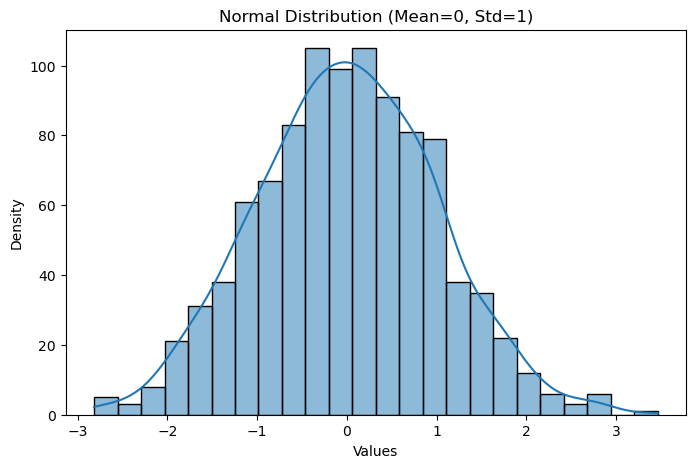

In [2]:
# Ans 1
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate data
data = np.random.normal(0, 1, 1000)

# Plot
plt.figure(figsize=(8,5))
sns.histplot(data, kde=True, edgecolor='black')
plt.title("Normal Distribution (Mean=0, Std=1)")
plt.xlabel("Values")
plt.ylabel("Density")
plt.show()

In [5]:
# Ans 2
# Scores simulate karna
mean_score = 70
std_dev = 10
scores = np.random.normal(mean_score, std_dev, 1000)

# 85 se upar wale students count karna
above_85 = np.mean(scores > 85) * 100

print("Percentage scoring above 85 is", round(above_85, 2), "%")

Percentage scoring above 85 is 7.1 %


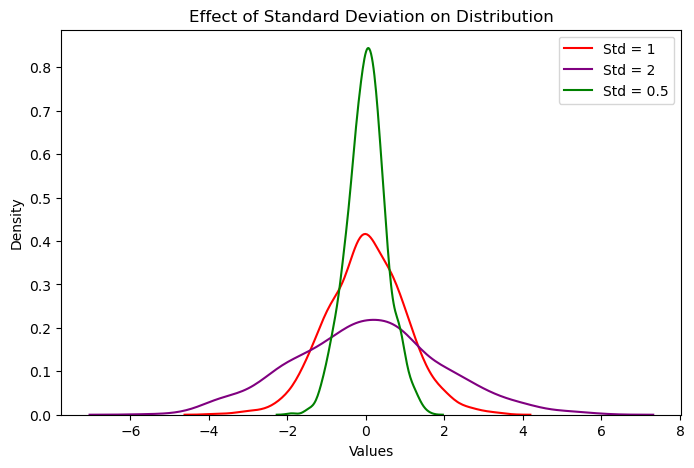

In [6]:
# Ans 3
# Jitna Standard Deviation (std) bara hoga, graph utna hi phel jaye ga (wide) aur height kam ho jaye gi. 
# Agar std chota hoga, toh graph patla (narrow) aur ooncha ho jaye ga.

# Generate datasets with different std
data1 = np.random.normal(0, 1, 1000)
data2 = np.random.normal(0, 2, 1000)
data3 = np.random.normal(0, 0.5, 1000)

# Plot
plt.figure(figsize=(8,5))
sns.kdeplot(data1, label="Std = 1",color='red')
sns.kdeplot(data2, label="Std = 2",color='purple')
sns.kdeplot(data3, label="Std = 0.5",color='green')

plt.title("Effect of Standard Deviation on Distribution")
plt.xlabel("Values")
plt.ylabel("Density")
plt.legend()
plt.show()

## 2. Binomial Distribution

**Q4:** Simulate 100 coin toss experiments with probability p=0.5. Plot distribution.

**Q5:** Model a scenario where a student guesses MCQs (4 options). What is probability of getting exactly 6 correct out of 10?

**Q6 (Thinking):** When does binomial start resembling normal distribution? Demonstrate.

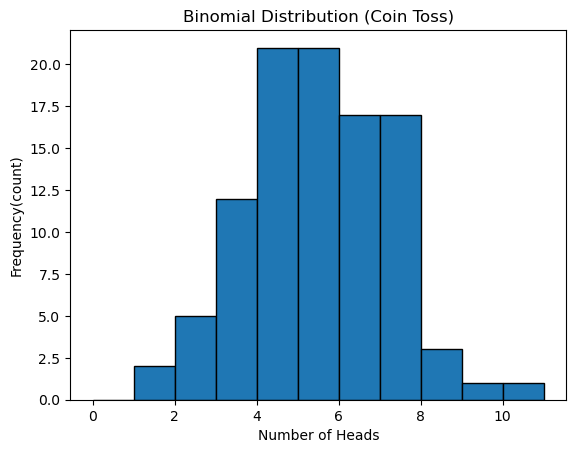

In [7]:
# Ans 4
n = 100 # Trials
p = 0.5 # Success probability (Heads)
# 100 experiments, each with 10 tosses
data = np.random.binomial(10, p, n)

plt.hist(data, bins=range(12), edgecolor='black')
plt.title("Binomial Distribution (Coin Toss)")
plt.xlabel("Number of Heads")
plt.ylabel("Frequency(count)")
plt.show()

In [59]:
# Ans 5
from scipy.stats import binom
n = 10
p = 0.25   #4 options ki waja sey probability 0.25 h 
prob = binom.pmf(6, n, p)
print(f"Probability of exactly 6 correct(X=6): {prob:.4f}")


Probability of exactly 6 correct(X=6): 0.0162


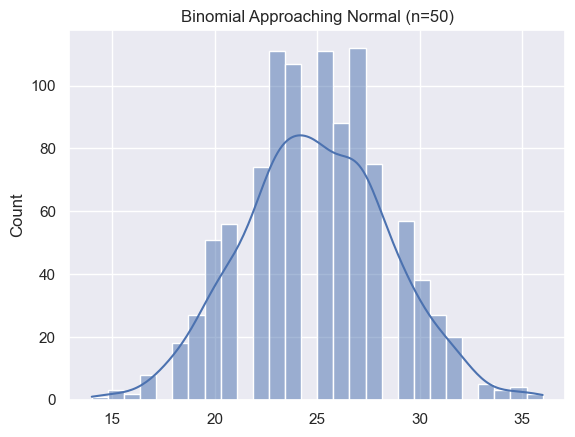

In [64]:
# Ans 6
# 50 sawal puche gaye hain probability 0.5 hai or ya process 1000 bar repeat howa h
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = np.random.binomial(n=50, p=0.5, size=1000)

sns.histplot(data, kde=True)
plt.title("Binomial Approaching Normal (n=50)")
plt.show()

## 3. Poisson Distribution

**Q7:** Model number of calls received per minute in a call center (lambda=5).

**Q8:** What is probability of receiving exactly 3 calls in a minute?

**Q9 (Thinking):** When should Poisson be used instead of Binomial? Simulate example.

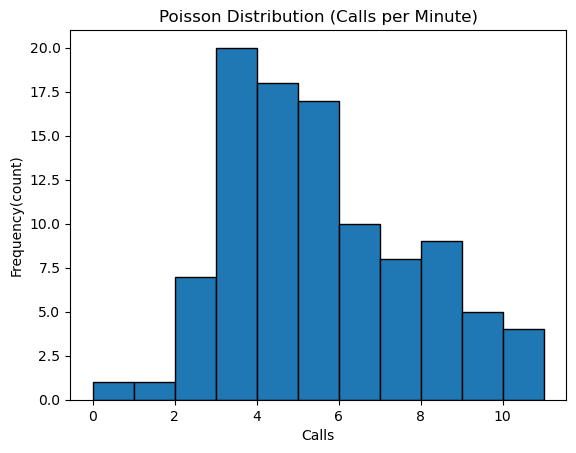

In [8]:
# Ans 7
# Data generate karna (100 minutes ki simulation)

data = np.random.poisson(lam=5, size=100)   # lam represent average

plt.hist(data, bins=range(12), edgecolor='black')
plt.title("Poisson Distribution (Calls per Minute)")
plt.xlabel("Calls")
plt.ylabel("Frequency(count)")
plt.show()

In [69]:
# Ans 8
from scipy.stats import poisson
lam=5
prob = poisson.pmf(3, 5)   #to calculate "exact" value probability
print(f"Exactly 3 calls aane ki probability(X=3):{prob_3:.4f}")

Exactly 3 calls aane ki probability(X=3):0.1404


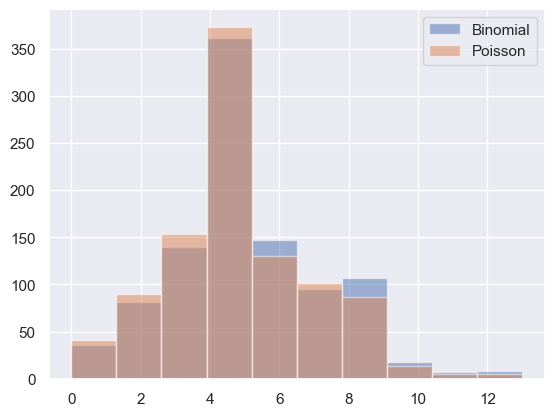

In [78]:
# Ans 9
# Binomial: Jab trials (n) fix hon aur aapko pata ho ke maximum kitne events ho sakte hain (e.g 100 coins mein se kitne heads).
# Poisson: events ek continuous time frame mein ho rahe hon(e.g. k ghante mein barish ke kitne qatray gire).
#Poisson is used when events are rare and trials are large.
# Statistics mein aik rule hai ke agar n>=100 ho aur p<= 0.05 ho, toh hum Binomial ki jagah Poisson use kar sakte hain.
# Is graph mein humne bilkul yahi conditions rakhi hain (n=100, p=0.05). 
# ik factory mei kitny product khrb ho sakty h

# Binomial (large n, small p)
bin_data = np.random.binomial(n=100, p=0.05, size=1000)

# Poisson
pois_data = np.random.poisson(lam=5, size=1000)

plt.hist(bin_data, alpha=0.5, label="Binomial")
plt.hist(pois_data, alpha=0.5, label="Poisson")
plt.legend()
plt.show()

## 4. Real-world Modeling + Pipeline

**Q10:** Create synthetic dataset where target follows a distribution.

**Q11:** Build a pipeline using sklearn that:
- Generates features
- Scales data
- Fits a model

**Q12 (Challenge):** Identify which distribution best fits given dataset.

Model Score: 0.9821528153293048


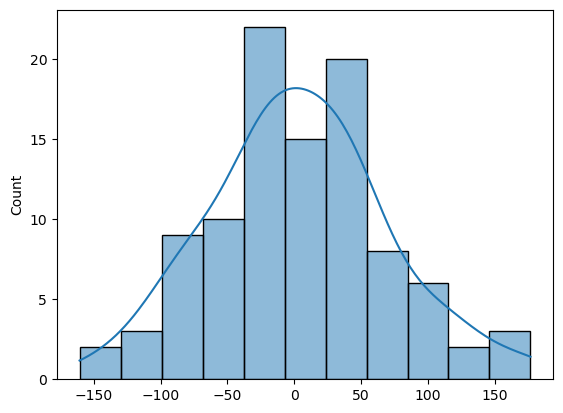

In [9]:
# Ans 10
from sklearn.datasets import make_regression

#X= features(rows=100,column=2)    y=output
X, y = make_regression(n_samples=100, n_features=2, noise=10)   #make_regression() = fake (synthetic) data generate karta hai

# Ans 11
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

#Pipeline = steps ko ek sath chalana
pipeline = Pipeline([
    ("scaler", StandardScaler()),  # Step 1: Scale Data (data ko ik range mei lana)
    ("model", LinearRegression())   # Step 2: Train model (input se output predict karna)
])

pipeline.fit(X, y)                                      #.fit() se model train hota hai
print(f"Model Score: {pipeline.score(X, y)}")           # .score represent ky model kitna acha hai

# Ans 12
import seaborn as sns

sns.histplot(y, kde=True)
plt.show()

In [10]:
# example of Real-world Modeling + Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import pandas as pd

# 1. Generates Features 
data = {'Study_Hours': [2, 5, 8, 10, 1]}
X = pd.DataFrame(data) # Input Features
y = [40, 65, 80, 95, 30]   # Target (Exam Scores)

# 2. Scales Data 
# Sab features ko ek hi scale (mean=0, std=1) par lana
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fits a Model (Training)
# Model ko sikhana ke Study Hours ka Scores se kya relation hai
model = LinearRegression()
model.fit(X_scaled, y)

print("Model is sucessfully train!")

Model is sucessfully train!


## 🎛 Interactive Visualization (ipywidgets)

**Q13:** Create sliders for:
- Mean (μ)
- Standard deviation (σ)
- Lambda (λ)

Plot distributions dynamically.


In [3]:
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from IPython.display import display

#(mean,std,lam)
def plot_interactive(mu, sigma, lam):  #Ye function slider ko move karti h
    x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
    y_norm = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_norm - mu) / sigma)**2)
    
    x_pois = np.arange(0, 20)
    y_pois = poisson.pmf(x_pois, lam)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Normal Plot
    ax1.plot(x_norm, y_norm, color='blue')
    ax1.set_title(f"Normal Distribution (μ={mu}, σ={sigma:.2f})")
    
    # Poisson Plot
    ax2.bar(x_pois, y_pois, color='orange', alpha=0.7)
    ax2.set_title(f"Poisson Distribution (λ={lam})")
    
    plt.show()

# Widgets
mu_slider = widgets.IntSlider(value=0, min=-10, max=10, description='Mean (μ):')
std_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, description='Std (σ):')
lam_slider = widgets.IntSlider(value=5, min=1, max=15, description='Lambda (λ):')

# Interactive output
ui = widgets.VBox([mu_slider, std_slider, lam_slider])
out = widgets.interactive_output(plot_interactive, {'mu': mu_slider, 'sigma': std_slider, 'lam': lam_slider})
#interactive_output aik function hai jo Python ko batata hai ke Jaise hi koi slider hile, foran graph ko update kar do.
display(ui, out)


Output()

## 📊 Distribution Fitting

**Q14:** Given a dataset, fit Normal, Poisson, and Binomial distributions.

**Q15:** Use likelihood or visual comparison to decide best fit.


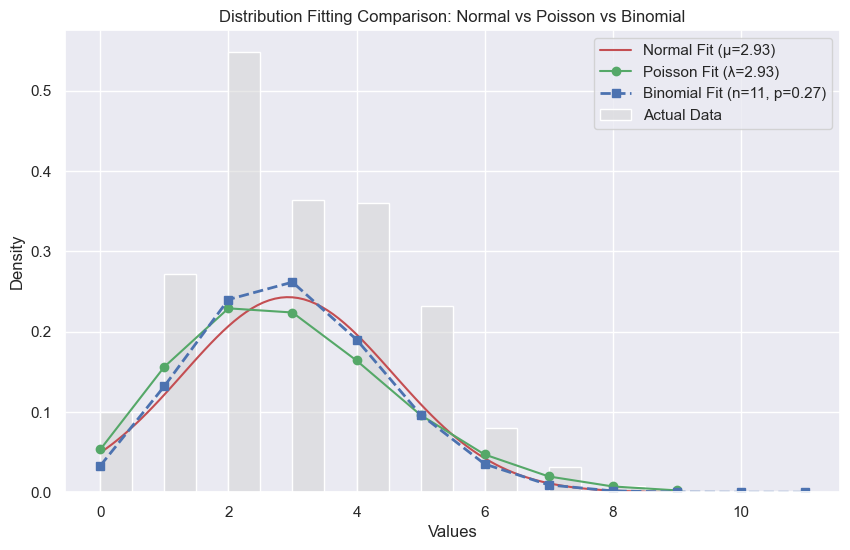

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Aik sample dataset banate hain (Poisson se generate kiya gaya)
data = np.random.poisson(lam=3, size=500)

# Visual Comparison ke liye plotting
plt.figure(figsize=(10, 6))
sns.histplot(data, stat="density", color='lightgrey', label="Actual Data", alpha=0.5)

# --- 1. Normal Fit ---
mu, std = stats.norm.fit(data)
x_norm = np.linspace(min(data), max(data), 100)
plt.plot(x_norm, stats.norm.pdf(x_norm, mu, std), 'r-', label=f"Normal Fit (μ={mu:.2f})")

# --- 2. Poisson Fit ---
lam_pois = np.mean(data)
x_pois = np.arange(0, max(data)+1)
plt.plot(x_pois, stats.poisson.pmf(x_pois, lam_pois), 'go-', label=f"Poisson Fit (λ={lam_pois:.2f})")

# --- 3. Binomial Fit (NEW) ---
# Binomial ke liye n (trials) chahiye hota hai. Hum n ko data ki max value ya koi bara number letay hain.
n_trials = int(max(data)) + 2  # Aik munasib n chun-na
p_est = lam_pois / n_trials    # p = Mean / n
x_bin = np.arange(0, n_trials + 1)
plt.plot(x_bin, stats.binom.pmf(x_bin, n_trials, p_est), 'bs--', lw=2, label=f"Binomial Fit (n={n_trials}, p={p_est:.2f})")

plt.title("Distribution Fitting Comparison: Normal vs Poisson vs Binomial")
plt.xlabel("Values")
plt.ylabel("Density")
plt.legend()
plt.show()

In [117]:
# Ans 15
# Likelihood Scores Check Karna
ll_norm = np.sum(stats.norm.logpdf(data, mu, std))
ll_pois = np.sum(stats.poisson.logpmf(data, lam_pois))
ll_bin = np.sum(stats.binom.logpmf(data, n_trials, p_est))

print(f"Normal Log-Likelihood: {ll_norm:.2f}")
print(f"Poisson Log-Likelihood: {ll_pois:.2f}")
print(f"Binomial Log-Likelihood: {ll_bin:.2f}")

Normal Log-Likelihood: -964.46
Poisson Log-Likelihood: -947.71
Binomial Log-Likelihood: -957.32


## 🌍 Real Dataset Integration

**Q16:** Load real dataset (e.g., traffic, rainfall, or stock data).

**Q17:** Identify which distribution best models the data.

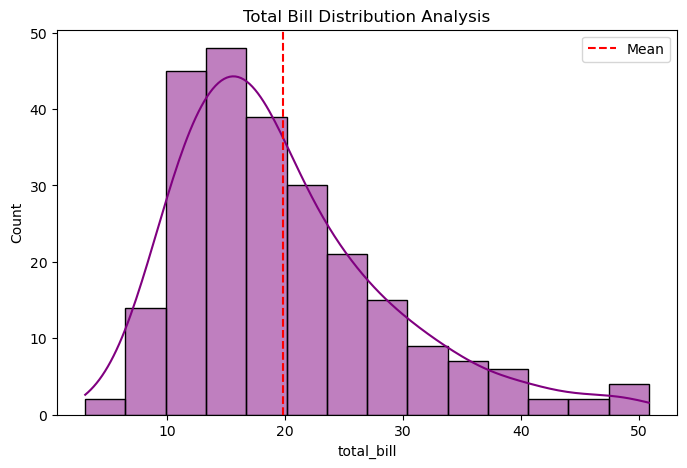

In [15]:
import seaborn as sns

# Real dataset load karna (Tips dataset)
tips = sns.load_dataset("tips")
data_points = tips['total_bill'] # Hum total bill ki distribution check karenge

# Visualization
plt.figure(figsize=(8, 5))
sns.histplot(data_points, kde=True, color='purple')
plt.title("Total Bill Distribution Analysis")
plt.axvline(data_points.mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()

# Q17: Identify Distribution
# Right-skewed / Exponential distribution
# The "tips" dataset is used to analyze the distribution of total bill amounts. 
# The histogram shows a right-skewed distribution, where most values are concentrated on the lower side, 
# and a few high values create a long tail. This indicates that the data does not follow a normal distribution 
# but resembles a skewed or exponential distribution.